> Copyright © 2026 Agnès REGAUD  
> Licence : [GNU Affero General Public License v3.0](../LICENSE) — `SPDX-License-Identifier: AGPL-3.0-only`

# Notebook 1 — Exploration et contrôle du dataset PCB Defect Dataset

- **But du projet :** comparer plusieurs modèles de détection d’objets afin d’identifier automatiquement des anomalies sur des cartes électroniques (PCB).
- **Dataset utilisé :** **PCB Defect Dataset**, stocké dans le projet sous `data/raw/pcb-defect-dataset` et décrit par le fichier `data.yaml`.
- **But de ce notebook :** réaliser le contrôle initial du dataset avant l’étape de benchmark des modèles : lecture de `data.yaml`, examen de l’arborescence, vérification de la cohérence des labels et contrôle des images.

# 1. Configuration et structure du dataset

## 1.1 Imports

In [1]:
from pathlib import Path
import yaml
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
from PIL import ImageDraw

import random
from collections import Counter

## 1.2 Définition des chemins du dataset

In [2]:
dataset_root = Path("../data/raw/pcb-defect-dataset")
dataset_yaml_path = dataset_root / "data.yaml"

dataset_root, dataset_yaml_path

(PosixPath('../data/raw/pcb-defect-dataset'),
 PosixPath('../data/raw/pcb-defect-dataset/data.yaml'))

## 1.3 Lecture du fichier `data.yaml`

In [3]:
with open(dataset_yaml_path, "r") as f:
    kaggle_data_config = yaml.safe_load(f)

kaggle_data_config

{'path': '../data/raw/pcb-defect-dataset/',
 'train': 'train',
 'val': 'val',
 'test': 'test',
 'names': {0: 'mouse_bite',
  1: 'spur',
  2: 'missing_hole',
  3: 'short',
  4: 'open_circuit',
  5: 'spurious_copper'}}

## 1.4 Arborescence du dataset

In [4]:
for path in sorted(dataset_root.iterdir()):
    print(path.name, "|", "dir" if path.is_dir() else "file")

.DS_Store | file
.ipynb_checkpoints | dir
data.yaml | file
test | dir
train | dir
val | dir


## 1.5 Dossiers contenus dans chaque split

In [5]:
for split_dir in sorted([p for p in dataset_root.iterdir() if p.is_dir()]):
    print(f"\n{split_dir.name}")
    for path in sorted(split_dir.iterdir()):
        print(" -", path.name)


.ipynb_checkpoints
 - data-checkpoint.yaml

test
 - .DS_Store
 - images
 - labels

train
 - .DS_Store
 - images
 - labels
 - labels.cache

val
 - .DS_Store
 - images
 - labels
 - labels.cache


## 1.6 Nombre de fichiers et de sous-dossiers par dossier

In [6]:
rows = []

for split in ["train", "val", "test"]:
    for subdir in ["images", "labels"]:
        folder = dataset_root / split / subdir
        rows.append({
            "split": split,
            "subdir": subdir,
            "num_files": len(list(folder.iterdir())),
        })

pd.DataFrame(rows)

,split,subdir,num_files
0,train,images,17068
1,train,labels,8534
2,val,images,2132
3,val,labels,1066
4,test,images,1069
5,test,labels,1069


## 1.7 Extensions détectées par dossier

In [7]:
rows = []

for split in ["train", "val", "test"]:
    for subdir in ["images", "labels"]:
        folder = dataset_root / split / subdir
        extensions = Counter(
            p.suffix.lower() if p.suffix else "[no extension]"
            for p in folder.iterdir()
        )

        for extension, count in sorted(extensions.items()):
            rows.append({
                "split": split,
                "subdir": subdir,
                "extension": extension,
                "count": count,
            })

pd.DataFrame(rows)

,split,subdir,extension,count
0,train,images,.jpg,8534
1,train,images,.npy,8534
2,train,labels,.txt,8534
3,val,images,.jpg,1066
4,val,images,.npy,1066
5,val,labels,.txt,1066
6,test,images,.jpg,1068
7,test,images,[no extension],1
8,test,labels,.txt,1068
9,test,labels,[no extension],1


## 1.8 Vérification des classes du dataset

In [8]:
dataset_classes = [kaggle_data_config["names"][i] for i in sorted(kaggle_data_config["names"])]
dataset_classes

['mouse_bite',
 'spur',
 'missing_hole',
 'short',
 'open_circuit',
 'spurious_copper']

## 1.9 Synthèse

## Synthèse de la structure du dataset

- Le dataset contient 3 splits : `train`, `val`, `test`.
- `train` : 8 534 labels `.txt`, 8 534 images `.jpg`, 8 534 fichiers `.npy`.
- `val` : 1 066 labels `.txt`, 1 066 images `.jpg`, 1 066 fichiers `.npy`.
- `test` : 1 068 labels `.txt`, 1 068 images `.jpg`.
- Le split `test` contient aussi 1 fichier sans extension dans `images/` et 1 dans `labels/`.
- Les labels sont au format YOLO : un fichier `.txt` par image annotée.
- Les 6 classes attendues sont bien définies dans `data.yaml`.

# 2. Contrôle des labels

## 2.1 Lecture de quelques fichiers labels

In [9]:
for split in ["train", "val", "test"]:
    label_dir = dataset_root / split / "labels"
    label_files = sorted(label_dir.glob("*.txt"))[:3]

    print(f"\n{split.upper()}")
    for label_file in label_files:
        print(f"\n--- {label_file.name} ---")
        with open(label_file, "r") as f:
            print(f.read())


TRAIN

--- l_light_01_missing_hole_01_1_600.txt ---
2 0.4350 0.7008 0.0700 0.0550


--- l_light_01_missing_hole_01_2_600.txt ---
2 0.6367 0.0508 0.0667 0.0617
2 0.7575 0.5333 0.0717 0.0600


--- l_light_01_missing_hole_02_1_600.txt ---
2 0.5633 0.2783 0.0667 0.0667
2 0.3208 0.8733 0.0383 0.0567


VAL

--- l_light_01_missing_hole_03_1_600.txt ---
2 0.6258 0.5350 0.0483 0.0433
2 0.0292 0.6317 0.0517 0.0367


--- l_light_01_missing_hole_11_1_600.txt ---
2 0.5483 0.9250 0.0800 0.0733


--- l_light_01_missing_hole_11_5_600.txt ---
2 0.5142 0.4742 0.0583 0.0650


TEST

--- l_light_01_missing_hole_04_2_600.txt ---
2 0.3808 0.1575 0.0483 0.0583
2 0.2600 0.4242 0.0600 0.0583


--- l_light_01_missing_hole_07_2_600.txt ---
2 0.7617 0.0533 0.0567 0.0533
2 0.4100 0.8042 0.0800 0.0817


--- l_light_01_missing_hole_08_1_600.txt ---
2 0.5367 0.5458 0.0567 0.0583



## 2.2 Vérification des ids de classes présents dans les labels

In [10]:
class_ids = set()

for split in ["train", "val", "test"]:
    label_dir = dataset_root / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_ids.add(class_id)

sorted(class_ids)

[0, 1, 2, 3, 4, 5]

## 2.3 Vérification de la correspondance entre images et labels

In [11]:
rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_root / split / "images"
    label_dir = dataset_root / split / "labels"

    image_stems = {p.stem for p in image_dir.glob("*.jpg")}
    label_stems = {p.stem for p in label_dir.glob("*.txt")}

    rows.append({
        "split": split,
        "images_without_label": len(image_stems - label_stems),
        "labels_without_image": len(label_stems - image_stems),
    })

pd.DataFrame(rows)

,split,images_without_label,labels_without_image
0,train,2164,2164
1,val,264,264
2,test,239,239


In [12]:
for split in ["train", "val", "test"]:
    image_stems = {p.stem for p in (dataset_root / split / "images").glob("*.jpg")}
    label_stems = {p.stem for p in (dataset_root / split / "labels").glob("*.txt")}

    print(f"\n{split}")
    print("images sans label :", sorted(image_stems - label_stems)[:5])
    print("labels sans image :", sorted(label_stems - image_stems)[:5])


train
images sans label : ['light_01_missing_hole_01_1_600', 'light_01_missing_hole_01_2_600', 'light_01_missing_hole_02_1_600', 'light_01_missing_hole_03_1_600', 'light_01_missing_hole_04_1_600']
labels sans image : ['light_01_missing_hole_01_1_256', 'light_01_missing_hole_01_2_256', 'light_01_missing_hole_02_1_256', 'light_01_missing_hole_03_1_256', 'light_01_missing_hole_04_1_256']

val
images sans label : ['light_01_missing_hole_02_2_600', 'light_01_missing_hole_03_2_600', 'light_01_missing_hole_05_1_600', 'light_01_missing_hole_07_2_600', 'light_01_missing_hole_09_1_600']
labels sans image : ['light_01_missing_hole_02_2_256', 'light_01_missing_hole_03_2_256', 'light_01_missing_hole_05_1_256', 'light_01_missing_hole_07_2_256', 'light_01_missing_hole_09_1_256']

test
images sans label : ['light_01_missing_hole_02_3_600', 'light_01_missing_hole_05_2_600', 'light_01_missing_hole_06_3_600', 'light_01_missing_hole_07_1_600', 'light_01_missing_hole_08_2_600']
labels sans image : ['light

In [13]:
rows = []

for split in ["train", "val", "test"]:
    image_stems = {
        "_".join(p.stem.split("_")[:-1])
        for p in (dataset_root / split / "images").glob("*.jpg")
    }
    label_stems = {
        "_".join(p.stem.split("_")[:-1])
        for p in (dataset_root / split / "labels").glob("*.txt")
    }

    rows.append({
        "split": split,
        "images_without_label": len(image_stems - label_stems),
        "labels_without_image": len(label_stems - image_stems),
    })

pd.DataFrame(rows)

,split,images_without_label,labels_without_image
0,train,0,0
1,val,0,0
2,test,0,0


## --> Les images `.jpg` et les labels `.txt` correspondent bien aux mêmes échantillons après suppression du suffixe final. Les noms utilisent un suffixe différent (`_600` côté image, `_256` côté label), mais l’identifiant principal de l’échantillon est commun.

In [14]:
sample = "light_01_missing_hole_01_1"

img_path = next((dataset_root / "train" / "images").glob(f"{sample}_*.npy"))
label_path = next((dataset_root / "train" / "labels").glob(f"{sample}_*.txt"))

print(img_path.name)
print(label_path.name)
print(label_path.read_text())

light_01_missing_hole_01_1_600.npy
light_01_missing_hole_01_1_256.txt
2 0.4350 0.7008 0.0700 0.0550



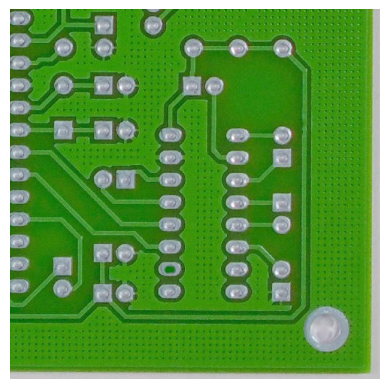

In [15]:
img = np.load(img_path)
plt.imshow(img)
plt.axis("off");

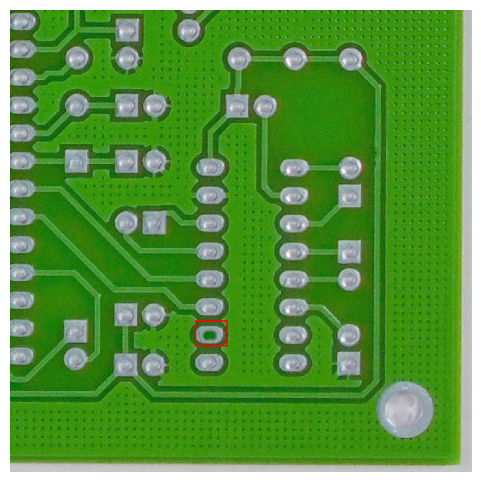

In [16]:
img_array = np.load(img_path)

if img_array.shape[0] == 3:
    img_array = img_array.transpose(1, 2, 0)

img = Image.fromarray(img_array.astype("uint8")).convert("RGB")


w, h = img.size

img_draw = img.copy()
draw = ImageDraw.Draw(img_draw)

with open(label_path, "r") as f:
    for line in f:
        class_id, x_center, y_center, bw, bh = map(float, line.split())

        x_center *= w
        y_center *= h
        bw *= w
        bh *= h

        x1 = x_center - bw / 2
        y1 = y_center - bh / 2
        x2 = x_center + bw / 2
        y2 = y_center + bh / 2

        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

plt.figure(figsize=(6, 6))
plt.imshow(img_draw)
plt.axis("off");

## --> Les images et les labels utilisent un suffixe final différent (_600 vs _256), mais correspondent bien aux mêmes échantillons. La vérification visuelle confirme que les annotations sont correctement alignées.

## 2.4 Distribution des classes par split

In [17]:
split_class_counts = []

for split in ["train", "val", "test"]:
    label_dir = dataset_root / split / "labels"
    class_counts = Counter()

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

    for class_id, count in sorted(class_counts.items()):
        split_class_counts.append({
            "split": split,
            "class_id": class_id,
            "class_name": dataset_classes[class_id],
            "count": count,
        })

split_class_distribution = pd.DataFrame(split_class_counts)
split_class_distribution.pivot(index="class_name", columns="split", values="count")

split,test,train,val
class_name,,,
missing_hole,379,2902,331
mouse_bite,332,2980,372
open_circuit,345,2844,359
short,366,2731,411
spur,348,2919,369
spurious_copper,388,2966,322


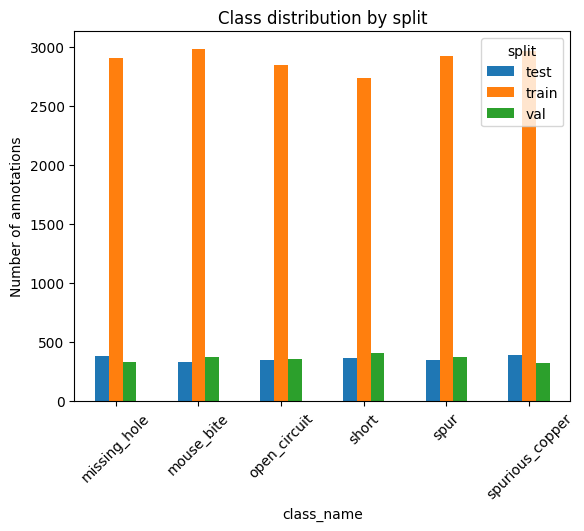

In [18]:
pivot_df = split_class_distribution.pivot(index="class_name", columns="split", values="count")
pivot_df.plot.bar(rot=45)
plt.title("Class distribution by split")
plt.ylabel("Number of annotations")
plt.show()

## 2.5 Distribution du nombre d’objets annotés par image

### 2.5.1 Tableau

In [19]:
rows = []

for split in ["train", "val", "test"]:
    label_dir = dataset_root / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            n_objects = sum(1 for line in f if line.strip())

        rows.append({
            "split": split,
            "label": label_file.stem,
            "n_objects": n_objects,
        })

objects_per_image = pd.DataFrame(rows)
objects_per_image.groupby("split")["n_objects"].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,1068.0,2.020599,1.002128,1.0,1.0,2.0,3.0,5.0
train,8534.0,2.032107,1.016055,1.0,1.0,2.0,3.0,5.0
val,1066.0,2.030019,1.031449,1.0,1.0,2.0,3.0,5.0


### 2.5.2 Histogramme du nombre d'objets annotés

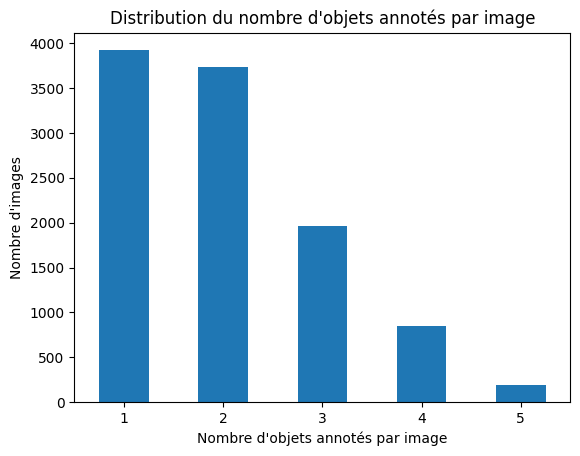

In [20]:
objects_per_image["n_objects"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Nombre d'objets annotés par image")
plt.ylabel("Nombre d'images")
plt.title("Distribution du nombre d'objets annotés par image")
plt.xticks(rotation=0)
plt.show()

### Le nombre d’objets par image est stable d’un split à l’autre : environ 2 annotations par image en moyenne, avec des valeurs comprises entre 1 et 5.

## 2.6 Vérification de la taille des bounding boxes

### 2.6.1 Tableau

In [21]:
rows = []

for split in ["train", "val", "test"]:
    label_dir = dataset_root / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                if line.strip():
                    class_id, x_center, y_center, width, height = map(float, line.split())
                    rows.append({
                        "split": split,
                        "class_id": int(class_id),
                        "width": width,
                        "height": height,
                        "area": width * height,
                    })

bbox_stats = pd.DataFrame(rows)
bbox_stats.groupby("split")[["width", "height", "area"]].agg(
    ["mean", "std", "min", "median", "max"]
)

width                                      height                    \
           mean       std     min  median     max      mean       std     min   
split                                                                           
test   0.050923  0.020332  0.0183  0.0467  0.1567  0.050818  0.020412  0.0133   
train  0.050471  0.020234  0.0150  0.0466  0.1967  0.050530  0.020435  0.0133   
val    0.050431  0.019721  0.0150  0.0466  0.1883  0.049911  0.018590  0.0150   

                           area                                          
       median     max      mean       std       min    median       max  
split                                                                    
test   0.0466  0.1983  0.002649  0.001792  0.000458  0.002174  0.024788  
train  0.0466  0.1983  0.002612  0.001779  0.000366  0.002161  0.024788  
val    0.0458  0.1464  0.002556  0.001511  0.000458  0.002165  0.011875

### --> La taille des bounding boxes est très proche d’un split à l’autre. Les largeurs et hauteurs moyennes sont d’environ 0,05 en coordonnées normalisées, avec une médiane proche de 0,046. Les surfaces sont également homogènes entre train, validation et test, avec une médiane autour de 0,0022. Cela indique une bonne cohérence de taille des défauts annotés dans l’ensemble du dataset.

### 2.6.2 Histogramme des tailles des bounding boxes

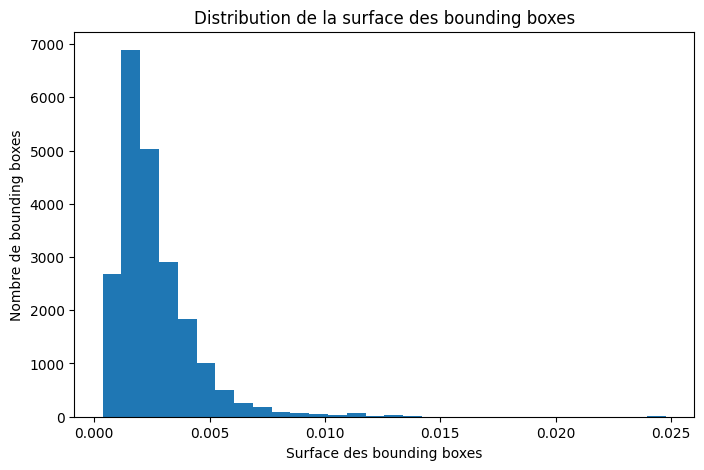

In [22]:
plt.figure(figsize=(8, 5))
bbox_stats["area"].hist(bins=30)
plt.xlabel("Surface des bounding boxes")
plt.ylabel("Nombre de bounding boxes")
plt.title("Distribution de la surface des bounding boxes")
plt.grid(False)
plt.show()

### La surface des bounding boxes est calculée ici à partir de largeurs et hauteurs normalisées. Elle représente donc une proportion de la surface de l’image, et non une surface exprimée en pixels. En moyenne la surface des bounding boxes est de 0,0026 soit 0,26% de la surface de l'image.

### --> Les défauts annotés sont globalement de petite taille, ce qui confirme qu’il s’agit d’un problème de détection d’objets fins.

## 2.7 Vérification de la validité des coordonnées des bounding boxes

In [23]:
rows = []

for split in ["train", "val", "test"]:
    label_dir = dataset_root / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                if line.strip():
                    class_id, x_center, y_center, width, height = map(float, line.split())
                    rows.append({
                        "split": split,
                        "valid": (
                            0 <= x_center <= 1
                            and 0 <= y_center <= 1
                            and 0 < width <= 1
                            and 0 < height <= 1
                        )
                    })

pd.DataFrame(rows).groupby("split")["valid"].value_counts()

split  valid
test   True      2158
train  True     17342
val    True      2164
Name: count, dtype: int64

## --> Toutes les bounding boxes vérifiées sont valides. Les coordonnées des centres sont bien comprises entre 0 et 1, et les largeurs comme les hauteurs sont strictement positives et bornées. Aucune annotation aberrante n’a été détectée sur ce point.

## 2.8 Contrôle : images contenant plusieurs types de défauts

In [24]:
rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_root / split / "images"

    for label_path in (dataset_root / split / "labels").glob("*.txt"):
        lines = [line for line in label_path.read_text().splitlines() if line.strip()]

        if len(lines) > 1:
            sample_id = "_".join(label_path.stem.split("_")[:-1])
            image_path = next(image_dir.glob(f"{sample_id}_*.jpg"), None)

            class_ids = [int(line.split()[0]) for line in lines]
            unique_classes = sorted({dataset_classes[i] for i in class_ids})

            rows.append(
                {
                    "split": split,
                    "image": image_path.name if image_path else None,
                    "n_defects": len(lines),
                    "classes": [dataset_classes[i] for i in class_ids],
                    "unique_classes": unique_classes,
                }
            )

multi_defect_df = pd.DataFrame(rows)

multi_type_df = multi_defect_df[
    multi_defect_df["unique_classes"].apply(len) >= 2
]

multi_type_df

,split,image,n_defects,classes,unique_classes


### --> Aucune image ne contient plusieurs types de défauts différents. Certaines images contiennent plusieurs annotations, mais elles correspondent au même type de défaut.

# 3 Contrôle des images

## 3.1 Vérification de la lisibilité des images

In [25]:
rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_root / split / "images"
    unreadable = 0
    total = 0

    for image_file in image_dir.glob("*.jpg"):
        total += 1
        try:
            with Image.open(image_file) as img:
                img.verify()
        except Exception:
            unreadable += 1

    rows.append({
        "split": split,
        "total_images": total,
        "unreadable_images": unreadable,
    })

pd.DataFrame(rows)

,split,total_images,unreadable_images
0,train,8534,0
1,val,1066,0
2,test,1068,0


## --> Toutes les images jpg sont lisibles dans les trois splits. Aucune image jpg corrompue ou illisible n’a été détectée.

## 3.2 Analyse des dimensions des images

In [26]:
rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_root / split / "images"

    for image_file in image_dir.glob("*.jpg"):
        with Image.open(image_file) as img:
            width, height = img.size

        rows.append({
            "split": split,
            "width": width,
            "height": height,
        })

image_sizes = pd.DataFrame(rows)
image_sizes.groupby("split")[["width", "height"]].agg(["min", "median", "max"])

width             height            
        min median  max    min median  max
split                                     
test    600  600.0  601    600  600.0  601
train   600  600.0  601    600  600.0  601
val     600  600.0  601    600  600.0  601

## --> Les dimensions des images sont très homogènes dans l’ensemble du dataset. Les images mesurent presque toutes 600 × 600 pixels, avec de rares variations à 601 pixels, sans impact notable sur la cohérence du jeu de données.

## 3.3 Vérification des canaux

In [27]:
rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_root / split / "images"
    modes = Counter()

    for image_file in image_dir.glob("*.jpg"):
        with Image.open(image_file) as img:
            modes[img.mode] += 1

    for mode, count in modes.items():
        rows.append({
            "split": split,
            "mode": mode,
            "count": count,
        })

pd.DataFrame(rows)

,split,mode,count
0,train,RGB,8534
1,val,RGB,1066
2,test,RGB,1068


## --> Toutes les images sont en mode RGB. Le dataset est donc homogène en nombre de canaux, sans présence d’images en niveaux de gris ni de canal alpha.

## 3.4 Contrôle rapide de la qualité visuelle

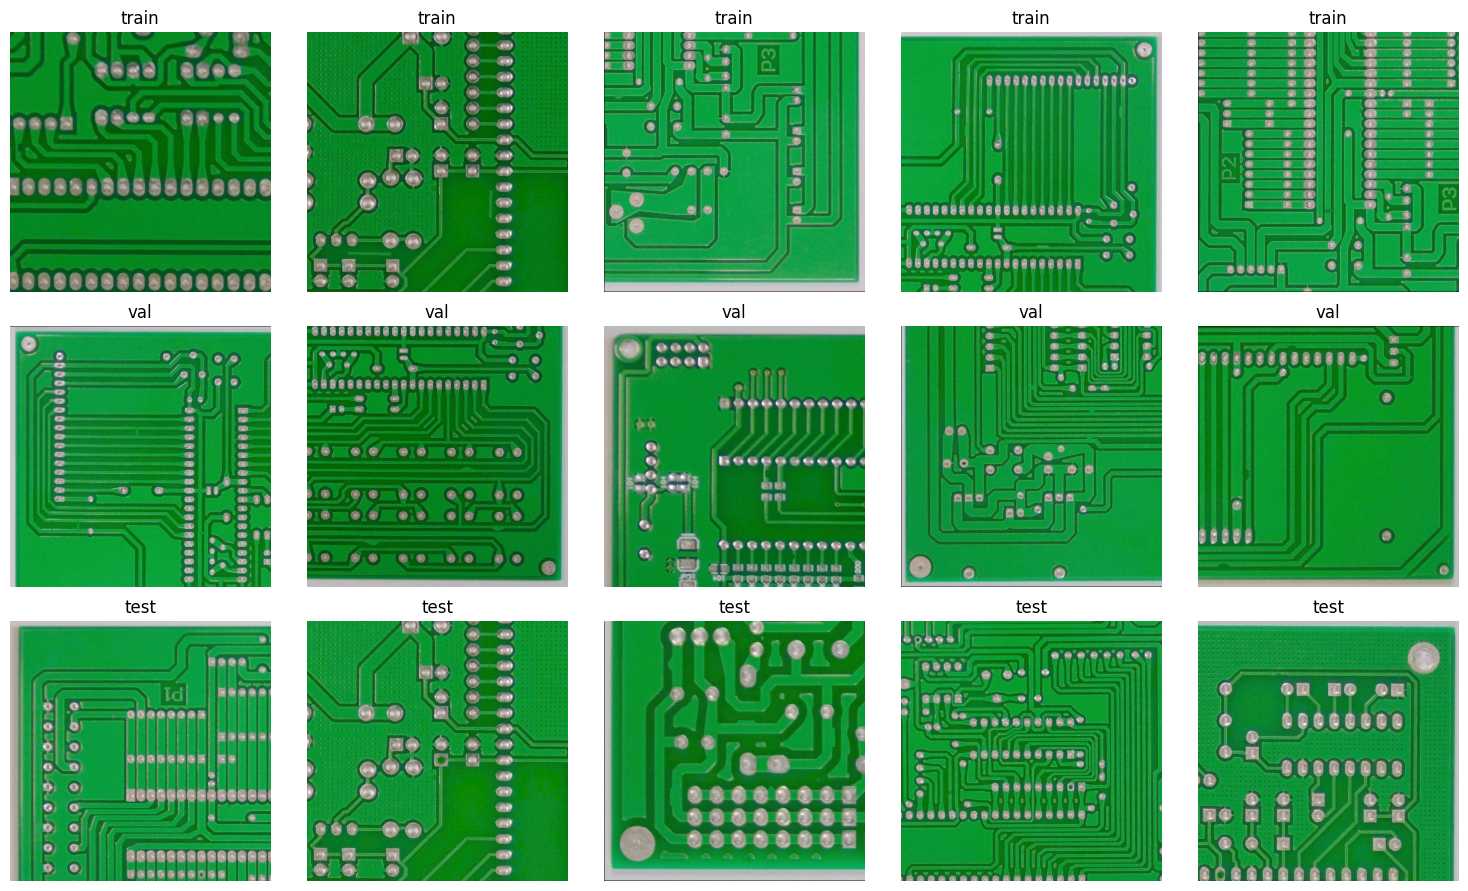

In [28]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row, split in enumerate(["train", "val", "test"]):
    image_files = sorted((dataset_root / split / "images").glob("*.jpg"))
    samples = random.sample(image_files, 5)

    for col, image_file in enumerate(samples):
        with Image.open(image_file) as img:
            axes[row, col].imshow(img)
        axes[row, col].set_title(split)
        axes[row, col].axis("off")

plt.tight_layout()

## --> Un contrôle visuel rapide sur un échantillon d’images de chaque split ne met pas en évidence d’anomalie manifeste de qualité. Les images apparaissent nettes, correctement cadrées et cohérentes visuellement entre train, validation et test.

# 4 Synthèse de l'exploration

## --> Le dataset apparaît globalement sain pour un projet de détection d’objets. Les labels `.txt` sont valides, les classes sont représentées dans chaque split, les images `.jpg` sont lisibles, homogènes en format RGB et majoritairement en 600 × 600 pixels. Aucun problème majeur d’intégrité n’a été détecté.